In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
config_path = "experiments/benchmark_output_files/zebrafish_head.yaml"
panel_output_path = "results/publication_oup_v2/figures/panels/panel_zebrafish_head.pdf"

In [18]:
import yaml
from pathlib import Path as P

cfg = yaml.safe_load(open(config_path))

output_dir = cfg["output_dir"]

global_structure_analysis_folder = P(output_dir) / "global_structure_analysis"

In [19]:
from src.experiments_analysis.plots_ismb import model_name_replacement_dict, color_dict
from pathlib import Path as P
bottom_region = (slice(2500, 3000), slice(2000, 3000))
central_blob_region = (slice(600, 700), slice(2320, 2380))
regions_dict = {"central blob": central_blob_region, "bottom region": bottom_region}
abbr_region = {"central blob": "A", "bottom region": "B"}

Using vmin, vmax = 0.0 594.2809166580777
overall striping intensity


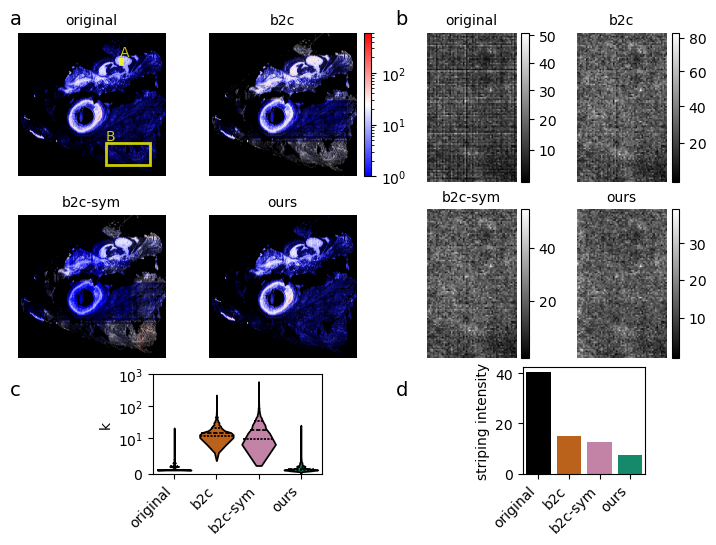

In [20]:
from src.experiments_analysis.analysis_plots import (
    compare_destriped_data_plots, striping_intensity_quantification_region_barplot, intensity_profile_in_region_violinplot
)
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, PowerNorm
from src.experiments_analysis.analysis_plots import slice_to_rect
from matplotlib.patches import Rectangle
import numpy as np
from matplotlib.gridspec import GridSpec
from src.utilities.matplotlib_utils import save_pdf_temp_intermediate

base_font_size = 10
fontsize_title = 10
plt.rcParams.update(
    {
        "font.size": base_font_size,  # base font size
        "axes.labelsize": base_font_size,  # x/y label size
        "axes.titlesize": base_font_size,  # title size
        "xtick.labelsize": base_font_size,  # x tick labels
        "ytick.labelsize": base_font_size,  # y tick labels
        "legend.fontsize": base_font_size,  # legend
    }
)

fig = plt.figure(layout="constrained", figsize=(7.009, 5.3))
gs = GridSpec(2, 2, width_ratios=[2, 1.5], height_ratios=[2, 1], figure=fig, hspace=0.3)

# global plots

gs_global = gs[0, 0].subgridspec(
    2, 2, height_ratios=[1,1], width_ratios = [1,1], wspace=0.0
)
axes = [
    fig.add_subplot(gs_global[0, 0]),
    fig.add_subplot(gs_global[0, 1]),
    fig.add_subplot(gs_global[1, 0]),
    fig.add_subplot(gs_global[1, 1]),
]

to_plot = ["original", "b2c", "b2c-sym", "ours"]
region_slice = (slice(None, None), slice(None, None))

axes = compare_destriped_data_plots(
    to_plot,
    global_structure_analysis_folder,
    region_slice,
    model_name_replacement_dict,
    axes=axes,
    cmap="bwr",
)

[ax.images[0].set_norm(LogNorm(vmin=1, vmax=600)) for ax in axes]
[ax.axis("off") for ax in axes]

for cax in np.array(fig.axes).flatten():
    if (
        (cax.get_label() != "<colorbar>")
        and (cax.get_title() != "b2c")
        and (cax.get_title() in to_plot)
    ):
        cax.get_images()[0].colorbar.ax.set_visible(False)
        #cax.get_images()[0].colorbar.ax.remove()

for region_name, slice_ in regions_dict.items():
    color = "yellow"
    rectangle_kwargs_ = {
        "fill": False,
        "linewidth": 2,
        "color": color,
        "alpha": 0.8,
    }
    x, y, w, h = slice_to_rect(slice_[0], slice_[1])
    axes[0].add_patch(Rectangle((x, y), w, h, **rectangle_kwargs_))
    axes[0].text(x, y, abbr_region[region_name], va="bottom", color=color, alpha=0.8)

# zoom plots

gs_zoom = gs[0, 1].subgridspec(
    2, 2, height_ratios=[1, 1], width_ratios=[1, 1], wspace=0.0, hspace=0.0
)
axes = [
    fig.add_subplot(gs_zoom[0, 0]),
    fig.add_subplot(gs_zoom[0, 1]),
    fig.add_subplot(gs_zoom[1, 0]),
    fig.add_subplot(gs_zoom[1, 1]),
]

central_blob_region = (slice(600, 700), slice(2320, 2380))
axes = compare_destriped_data_plots(
    to_plot,
    global_structure_analysis_folder,
    central_blob_region,
    model_name_replacement_dict,
    axes=axes,
    colorbar_same_scale=False,
)

[ax.images[0].set_norm(PowerNorm(0.9)) for ax in axes]
[ax.axis("off") for ax in axes]

# count distribution in region C
gs_count_distr = gs[1, 0].subgridspec(
    1, 3, width_ratios=[1, 2, 1], wspace=0.0, hspace=0.0
)
ax = fig.add_subplot(gs_count_distr[0, 1])

axes = intensity_profile_in_region_violinplot(
    bottom_region,
    to_plot,
    global_structure_analysis_folder,
    color_dict,
    model_name_replacement_dict,
    axes = ax
)

axes.set_yscale("symlog", linthresh=10)
axes.set_ylim(0, 1000)

# striping intensity
gs_striping_intensity = gs[1, 1].subgridspec(
    1, 3, width_ratios=[1, 2, 1], wspace=0.0, hspace=0.0
)
ax = fig.add_subplot(gs_striping_intensity[0, 1])


ax = striping_intensity_quantification_region_barplot(
    output_dir,
    central_blob_region,
    to_plot,
    color_dict,
    model_name_replacement_dict,
    cyto_select=False,
    axes=ax,
)
fig.canvas.draw()

letters_fontsize = 14
fig.text(0.0, 1.0, "a", ha="left", va="top", fontsize=letters_fontsize)
fig.text(0.55, 1.0, "b", ha="left", va="top", fontsize=letters_fontsize)
fig.text(0.0, 0.3, "c", ha="left", va="top", fontsize=letters_fontsize)
fig.text(0.55, 0.3, "d", ha="left", va="top", fontsize=letters_fontsize)

save_pdf_temp_intermediate("temp_outputs", panel_output_path, dpi = 600)

plt.show()